
# Univariate statistics

I wanted to see how far a simple ANOVA score can go when the dataset is full of extra noise columns. The original notebook had the right idea, so I kept the same breast-cancer example and made the split, selection, and evaluation cleaner.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [2]:

cancer = load_breast_cancer(as_frame=True)
rng = np.random.RandomState(42)

noise = pd.DataFrame(
    rng.normal(size=(len(cancer.data), 50)),
    columns=[f"noise_{i + 1}" for i in range(50)],
    index=cancer.data.index,
)

X = pd.concat([cancer.data, noise], axis=1)
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=0,
)

pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "benign_share": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)


,rows,benign_share
train,398,0.628141
test,171,0.625731



I fit the selector on the training split only. That matters here because the point is to score features without letting the test set influence which columns survive.


In [3]:

selector = SelectPercentile(score_func=f_classif, percentile=50)
selector.fit(X_train, y_train)

selected_mask = pd.Series(selector.get_support(), index=X.columns)
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

selection_summary = pd.Series(
    {
        "selected_features": int(selected_mask.sum()),
        "real_features_kept": int(selected_mask.iloc[: cancer.data.shape[1]].sum()),
        "noise_features_kept": int(selected_mask.iloc[cancer.data.shape[1] :].sum()),
    }
)

display(selection_summary.to_frame("count"))
scores.head(8).to_frame("f_score")


,count
selected_features,40
real_features_kept,27
noise_features_kept,13


,f_score
worst concave points,737.406508
mean concave points,668.940648
worst perimeter,654.544427
worst radius,625.919987
mean perimeter,517.039472
mean radius,479.590235
worst area,465.781909
mean concavity,456.750180


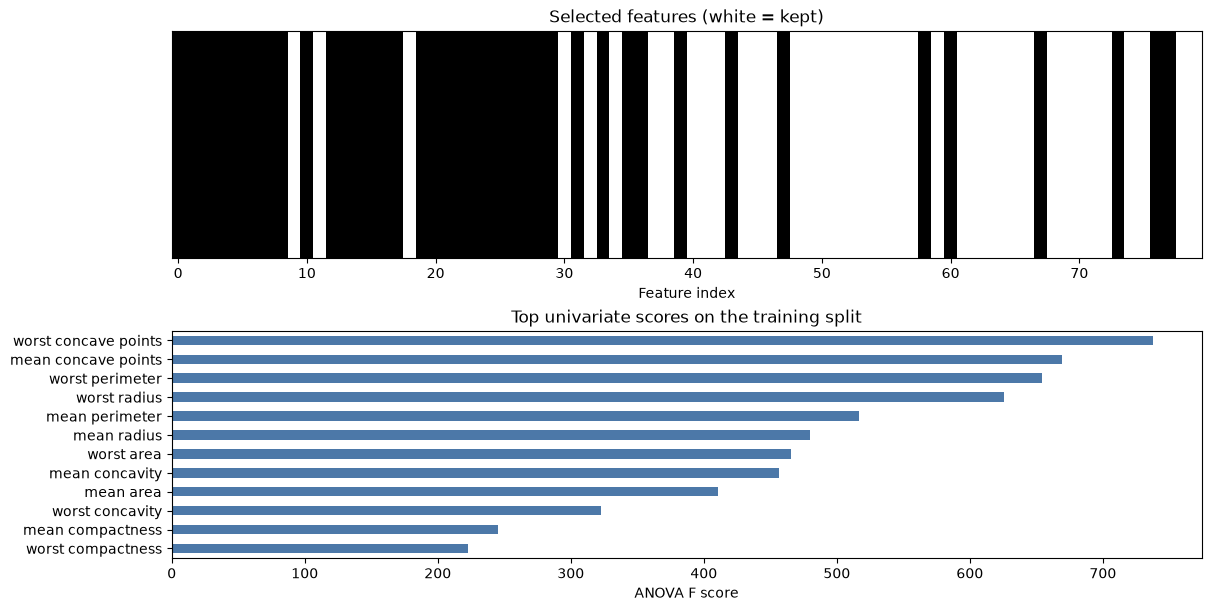

In [4]:

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].imshow(selected_mask.to_numpy().reshape(1, -1), aspect="auto", cmap="gray_r")
axes[0].set_yticks([])
axes[0].set_xlabel("Feature index")
axes[0].set_title("Selected features (white = kept)")

scores.head(12).sort_values().plot.barh(ax=axes[1], color="#4c78a8")
axes[1].set_xlabel("ANOVA F score")
axes[1].set_title("Top univariate scores on the training split")

plt.show()


In [5]:

baseline_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(solver="liblinear", max_iter=1000, random_state=0)),
    ]
)

selected_model = Pipeline(
    [
        ("select", SelectPercentile(score_func=f_classif, percentile=50)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(solver="liblinear", max_iter=1000, random_state=0)),
    ]
)

baseline_model.fit(X_train, y_train)
selected_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
selected_pred = selected_model.predict(X_test)

pd.DataFrame(
    {
        "accuracy": [
            (baseline_pred == y_test).mean(),
            (selected_pred == y_test).mean(),
        ],
        "mistakes": [
            int((baseline_pred != y_test).sum()),
            int((selected_pred != y_test).sum()),
        ],
    },
    index=["all_features", "selected_features"],
)


,accuracy,mistakes
all_features,0.923977,13
selected_features,0.953216,8


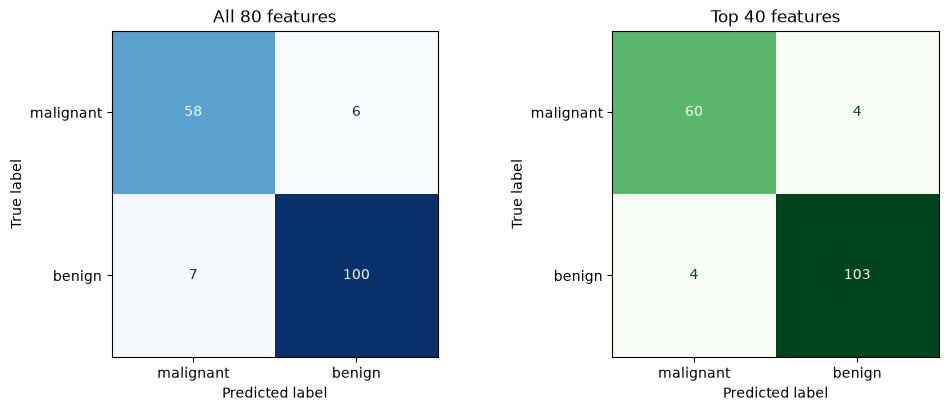

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_pred,
    display_labels=cancer.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("All 80 features")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_pred,
    display_labels=cancer.target_names,
    cmap="Greens",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Top 40 features")

plt.show()



## What I learned

The selector kept 27 of the 30 real breast-cancer features, but it still let 13 noise columns survive. The ranking still made sense because `worst concave points`, `mean concave points`, and the large radius and perimeter features dominated the score table.

On my saved split, the logistic-regression baseline reached about 0.924 accuracy, while the selected-feature version reached about 0.953. So the univariate filter did not remove every bad column, but it still cut the test mistakes from 13 to 8.
